In [ ]:
! pip install ultralytics opencv-python pyyaml numpy pandas scikit-learn torch matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 113.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [19]:
import cv2, os, random, shutil, zipfile, yaml
from pathlib import Path
import xml.etree.ElementTree as ET
from ultralytics import YOLO
import matplotlib.pyplot as plt


# configs
BASE_DIR = Path("/content/data/")
ARCHIVE_FILE = Path("/content/archive.zip")
DATASET_DIR = (BASE_DIR / "cleaned")
YOLO_DIR = (BASE_DIR / "processed")

YAML_PATH = ("data.yaml")
DATA_YAML = (YOLO_DIR / "data.yaml")
MODEL_ARCH = "models/yolov8m.pt"

FOLDERS = ["google_images", "video_images", "State-wise_OLX"]
PRO_FOLDERS = ["train", "valid", "test"]
SPLIT_RATIOS = (0.8, 0.1, 0.1)

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
PRO_IMG_EXTENSIONS = {".jpg", ".jpeg", ".png"}
ANNOTATION_EXT = ".xml"
YOLO_ANNOTATION_EXT = ".txt"

RUN_NAME = "anpr_v1"
RUN_NAME2 = "anpr_v2"
EPOCHS_DRY = 1
EPOCHS_HALF = 10
EPOCHS_FULL = 50
IMG_SIZE = 640
SAMPLES_TO_VISUALIZE = 5

In [ ]:
def extract_archive(archive_file: Path, extract_to: Path):
    """Extract the archive.zip file into the specified directory."""
    try:
        extract_to.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(archive_file, 'r') as zip_ref:
            zip_ref.extractall(extract_to)

        print(f"[INFO] Extracted archive: {archive_file} -> {extract_to}")
    except Exception as e:
        print(f"[ERROR] Failed to extract archive: {e}")

def collect_images(base_dir, folders, img_extensions=IMG_EXTENSIONS):
    """Collect all image paths from the specified folders and subfolders."""
    all_images = []

    try:
        for folder in folders:
            folder_path = base_dir / folder

            if not folder_path.exists():
                print(f"[WARN] Folder not found: {folder_path}")
                continue

            for root, _, files in os.walk(folder_path):
                for file in files:
                    if Path(file).suffix.lower() in img_extensions:
                        all_images.append(Path(root) / file)

        print(f"[INFO] Total images collected: {len(all_images)}")
    except Exception as e:
        print(f"[ERROR] Failed to collect images: {e}")
    return all_images

def split_dataset(images, ratios):
    """Split image paths into train, valid, and test sets."""
    try:
        random.shuffle(images)
        n_total = len(images)

        n_train = int(ratios[0] * n_total)
        n_valid = int(ratios[1] * n_total)

        train_set = images[:n_train]
        valid_set = images[n_train:n_train + n_valid]
        test_set = images[n_train + n_valid:]

        print(f"[INFO] Split: Train={len(train_set)}, Valid={len(valid_set)}, Test={len(test_set)}")
        return train_set, valid_set, test_set
    except Exception as e:
        print(f"[ERROR] Failed to split dataset: {e}")
        return [], [], []

def copy_files_with_annotations(images, target_dir, annotation_ext=ANNOTATION_EXT):
    """Copy images and their corresponding annotation files to the target directory."""
    try:
        target_dir.mkdir(parents=True, exist_ok=True)

        for img_path in images:
            try:
                # copy img
                shutil.copy(img_path, target_dir / img_path.name)

                # copy annotation (same name with .xml ext.)
                annotation_path = img_path.with_suffix(annotation_ext)

                if annotation_path.exists():
                    shutil.copy(annotation_path, target_dir / annotation_path.name)
                else:
                    print(f"[WARN] No annotation for {img_path.name}")

            except Exception as e:
                print(f"[ERROR] Failed to copy {img_path.name}: {e}")

    except Exception as e:
        print(f"[ERROR] Failed to copy files to {target_dir}: {e}")


def prepare_dataset(base_dir=BASE_DIR, output_dir=DATASET_DIR, folders=FOLDERS, split_ratios=SPLIT_RATIOS):
    """Main pipeline to prepare dataset."""
    try:
        # Step 0: Extract archive
        extract_archive(ARCHIVE_FILE, BASE_DIR)

        # Step 1: collect all imgs
        images = collect_images(base_dir, folders)
        if not images:
            print("[ERROR] No images found. Exiting...")
            return

        # Step 2: split dataset
        train_set, valid_set, test_set = split_dataset(images, split_ratios)

        # Step 3: copy files
        print("[INFO] Copying Train set...")
        copy_files_with_annotations(train_set, output_dir / "train")

        print("[INFO] Copying Valid set...")
        copy_files_with_annotations(valid_set, output_dir / "valid")

        print("[INFO] Copying Test set...")
        copy_files_with_annotations(test_set, output_dir / "test")

        print("[INFO] Dataset prepared successfully!")
    except Exception as e:
        print(f"[ERROR] Dataset preparation failed: {e}")

def check_annotations(split_dir, img_extensions=IMG_EXTENSIONS, annotation_ext=ANNOTATION_EXT):
    """Check images and annotation files in the split directory."""
    try:
        print(f"\n[INFO] Checking directory: {split_dir}")

        images = [f for f in split_dir.iterdir() if f.suffix.lower() in img_extensions]
        annotations = [f for f in split_dir.iterdir() if f.suffix.lower() == annotation_ext]

        image_names = {f.stem for f in images}
        annotation_names = {f.stem for f in annotations}

        # find missing annotations
        missing_annotations = image_names - annotation_names
        missing_images = annotation_names - image_names  # shouldn't exist ideally

        print(f"  Total Images: {len(images)}")
        print(f"  Total Annotations: {len(annotations)}")

        if missing_annotations:
            print(f"  [WARN] Missing annotations for {len(missing_annotations)} images:")
            for name in sorted(missing_annotations):
                print(f"    - {name}")
        else:
            print("  [INFO] All images have corresponding annotations.")

        if missing_images:
            print(f"  [WARN] Found annotations with no matching images:")
            for name in sorted(missing_images):
                print(f"    - {name}")

    except Exception as e:
        print(f"[ERROR] Failed to check {split_dir}: {e}")


def verify_dataset(dataset_dir=DATASET_DIR):
    """Verify annotations in train, valid, and test directories."""
    try:
        for split in ["train", "valid", "test"]:
            split_dir = dataset_dir / split
            if not split_dir.exists():
                print(f"[WARN] Split directory not found: {split_dir}")
                continue
            check_annotations(split_dir)
        print("\n[INFO] Dataset verification complete.")
    except Exception as e:
        print(f"[ERROR] Dataset verification failed: {e}")

In [ ]:
def run_stage_01():
    prepare_dataset()
    verify_dataset()

run_stage_01()

[INFO] Extracted archive: /content/archive.zip -> /content/data
[INFO] Total images collected: 1698
[INFO] Split: Train=1358, Valid=169, Test=171
[INFO] Copying Train set...
[INFO] Copying Valid set...
[INFO] Copying Test set...
[INFO] Dataset prepared successfully!

[INFO] Checking directory: /content/data/cleaned/train
  Total Images: 1358
  Total Annotations: 1356
  [INFO] All images have corresponding annotations.

[INFO] Checking directory: /content/data/cleaned/valid
  Total Images: 169
  Total Annotations: 169
  [INFO] All images have corresponding annotations.

[INFO] Checking directory: /content/data/cleaned/test
  Total Images: 171
  Total Annotations: 171
  [INFO] All images have corresponding annotations.

[INFO] Dataset verification complete.


In [ ]:
def create_yolo_dirs(pro_folders=PRO_FOLDERS, output_dir=YOLO_DIR):
    for split in pro_folders:
        (output_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (output_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

def convert_xml_to_yolo(xml_file, img_path, label_path):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        img_w = int(root.find("size/width").text)
        img_h = int(root.find("size/height").text)

        yolo_labels = []
        for obj in root.findall("object"):
            bbox = obj.find("bndbox")
            if bbox is None:
                print(f"[WARN] No bounding box in {xml_file}")
                continue

            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)

            # convert to the format that yolo accepts
            x_center = (((xmin + xmax) / 2) / img_w)
            y_center = (((ymin + ymax) / 2) / img_h)
            w = ((xmax - xmin) / img_w)
            h = ((ymax - ymin) / img_h)

            yolo_labels.append(f"0 {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")

        if not yolo_labels:
            print(f"[WARN] No objects found in {xml_file}")

        # write to label file
        with open(label_path, "w") as f:
            f.write("\n".join(yolo_labels))
    except Exception as e:
        print(f"[ERROR] Failed to convert {xml_file}: {e}")


def preprocess_dataset(pro_folders=PRO_FOLDERS, dataset_dir=DATASET_DIR, output_dir=YOLO_DIR, pro_img_extensions=PRO_IMG_EXTENSIONS, annotation_ext=ANNOTATION_EXT, yolo_annotation_ext=YOLO_ANNOTATION_EXT):

    print("[INFO] Starting pre-processing...")
    create_yolo_dirs()
    print("[INFO] Created necessary directories for YOLO format.")

    for split in pro_folders:
        img_dir = dataset_dir / split
        for img_file in img_dir.iterdir():
            if img_file.suffix.lower() not in pro_img_extensions:
                continue

            sml_file = img_file.with_suffix(annotation_ext)
            target_img_path = output_dir / "images" / split / img_file.name
            target_lbl_path = output_dir / "labels" / split / (img_file.stem + yolo_annotation_ext)

            shutil.copy(img_file, target_img_path)
            if sml_file.exists():
                convert_xml_to_yolo(sml_file, img_file, target_lbl_path)
            else:
                print(f"[WARN] No annotation found for {img_file.name}, creating empty label.")
                open(target_lbl_path, "w").close()

    print("[INFO] Pre-processing completed!")


def validate_yolo_dataset(pro_folders, output_dir):
    """
    Validate the YOLO dataset structure:
    - Ensures images and labels are paired correctly
    - Counts number of images and annotations per split
    """
    print("[INFO] Starting YOLO dataset validation...")

    for split in pro_folders:
        img_dir = output_dir / "images" / split
        lbl_dir = output_dir / "labels" / split

        if not img_dir.exists() or not lbl_dir.exists():
            print(f"[ERROR] Missing directory for split: {split}")
            continue

        images = [f for f in img_dir.iterdir() if f.is_file()]
        labels = [f for f in lbl_dir.iterdir() if f.is_file()]

        image_names = {f.stem for f in images}
        label_names = {f.stem for f in labels}

        missing_labels = image_names - label_names
        extra_labels = label_names - image_names

        print(f"\n[INFO] Split: {split}")
        print(f"  Total Images: {len(images)}")
        print(f"  Total Labels: {len(labels)}")

        if missing_labels:
            print(f"  [WARN] Missing annotations for {len(missing_labels)} images:")
            for name in sorted(missing_labels):
                print(f"    - {name}")

        if extra_labels:
            print(f"  [WARN] Labels without matching images ({len(extra_labels)}):")
            for name in sorted(extra_labels):
                print(f"    - {name}")

    print("\n[INFO] YOLO dataset validation complete.")


def generate_data_yaml(output_dir, yaml_path=YAML_PATH):
    """
    Generate YOLOv8 data.yaml for training.
    """
    data_config = {
        "train": str((output_dir / "images" / "train").resolve()),
        "val": str((output_dir / "images" / "valid").resolve()),
        "test": str((output_dir / "images" / "test").resolve()),
        "nc": 1,  # number of classes
        "names": ["license_plate"]  # class names
    }

    yaml_path = Path(output_dir) / yaml_path
    with open(yaml_path, "w") as f:
        yaml.dump(data_config, f, default_flow_style=False)

    print(f"[INFO] data.yaml created at: {yaml_path}")
    return yaml_path

In [ ]:
def run_stage_02():
    preprocess_dataset()
    validate_yolo_dataset(PRO_FOLDERS, YOLO_DIR)
    generate_data_yaml(YOLO_DIR)

run_stage_02()

[INFO] Starting pre-processing...
[INFO] Created necessary directories for YOLO format.
[INFO] Pre-processing completed!
[INFO] Starting YOLO dataset validation...

[INFO] Split: train
  Total Images: 1358
  Total Labels: 1356

[INFO] Split: valid
  Total Images: 169
  Total Labels: 169

[INFO] Split: test
  Total Images: 171
  Total Labels: 171

[INFO] YOLO dataset validation complete.
[INFO] data.yaml created at: /content/data/processed/data.yaml


In [14]:
# STEP 1: SANITY CHECK (VISUALIZE ANNOTATIONS)
def visualize_samples(data_yaml, pro_dir, yolo_annotation_ext, samples):

    dataset_path = pro_dir / "images" / "train"
    label_path = pro_dir / "labels" / "train"
    all_images = list(dataset_path.glob("*.jpg")) + list(dataset_path.glob("*.jpeg")) + list(dataset_path.glob("*.png"))

    random.shuffle(all_images)

    print(f"[INFO] Visualizing {samples} random samples with bounding boxes...")
    for img_file in all_images[:samples]:
        label_file = label_path / (img_file.stem + yolo_annotation_ext)
        img = cv2.imread(str(img_file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if label_file.exists():
            h, w, _ = img.shape
            with open(label_file, "r") as f:
                lines = f.readlines()
                for line in lines:
                    cls, x, y, bw, bh = map(float, line.strip().split())
                    x, y, bw, bh = x * w, y * h, bw * w, bh * h
                    x1, y1 = int(x - bw/2), int(y - bh/2)
                    x2, y2 = int(x + bw/2), int(y + bh/2)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(img, "license_plate", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

        plt.imshow(img)
        plt.axis("off")
        plt.show()

# STEP 2: DRY RUN TRAINING
def dry_run_training(data_yaml, model_arch, epochs, imgsz, run_name):
    print(f"[INFO] Starting Dry Run (epochs={epochs})...")
    model = YOLO(model_arch)
    model.train(
        data=data_yaml,
        epochs=epochs,
        imgsz=imgsz,
        project="runs/detect",
        name=run_name + "_dry",
        verbose=True,
        plots=True,
    )
    print("[INFO] Dry Run Completed. Check runs/detect folder.")

# STEP 3: FULL TRAINING
def full_training(data_yaml, model_arch, epochs, imgsz, run_name):
    print(f"[INFO] Starting Full Training (epochs={epochs})...")
    model = YOLO(model_arch)
    model.train(
        data=data_yaml,
        epochs=epochs,
        imgsz=imgsz,
        project="runs/detect",
        name=run_name,
        verbose=True,
        plots=True,
    )
    print("[INFO] Full Training Completed. Check runs/detect folder.")

[INFO] Visualizing 5 random samples with bounding boxes...


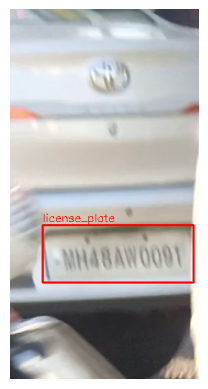

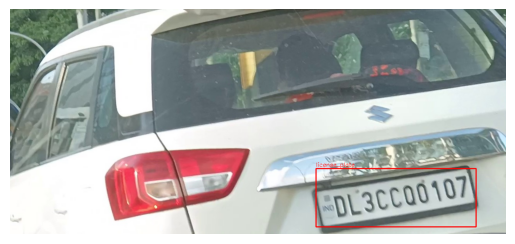

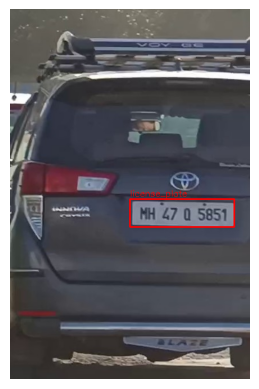

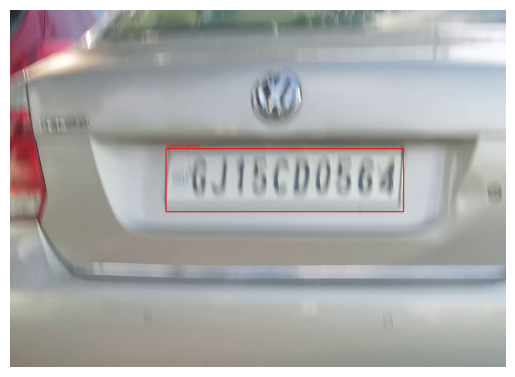

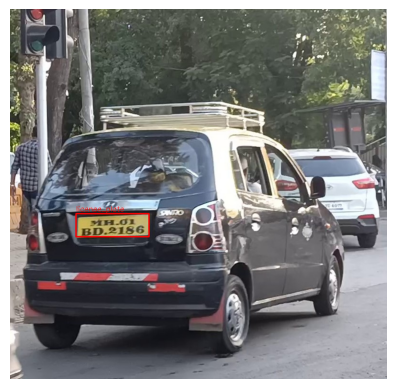

In [15]:
# STEP 1: Visualize Sample Images
visualize_samples(DATA_YAML, YOLO_DIR, YOLO_ANNOTATION_EXT, SAMPLES_TO_VISUALIZE)

In [16]:
# STEP 2: Dry Run
dry_run_training(DATA_YAML, MODEL_ARCH, EPOCHS_DRY, IMG_SIZE, RUN_NAME)

[INFO] Starting Dry Run (epochs=1)...


100%|██████████| 49.7M/49.7M [00:00<00:00, 138MB/s]


Ultralytics 8.3.169 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/processed/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=models/yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=anpr_v1_dry, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose

100%|██████████| 5.35M/5.35M [00:00<00:00, 337MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2163.0±838.6 MB/s, size: 115.3 KB)


...

Plotting labels to runs/detect/anpr_v1_dry/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/anpr_v1_dry
Starting training for 1 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/1      6.23G      1.012      1.293      1.062         25        640: 100%|██████████| 85/85 [00:44<00:00,  1.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:06<00:00,  1.08s/it]


                   all        169        169     0.0283      0.882     0.0278      0.019

1 epochs completed in 0.015 hours.
Optimizer stripped from runs/detect/anpr_v1_dry/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/anpr_v1_dry/weights/best.pt, 52.0MB

Validating runs/detect/anpr_v1_dry/weights/best.pt...
Ultralytics 8.3.169 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:04<00:00,  1.25it/s]


                   all        169        169     0.0281      0.882     0.0277      0.019
Speed: 0.2ms preprocess, 9.2ms inference, 0.0ms loss, 5.7ms postprocess per image
Results saved to runs/detect/anpr_v1_dry
[INFO] Dry Run Completed. Check runs/detect folder.


In [18]:
# STEP 3: Full Training
full_training(DATA_YAML, MODEL_ARCH, EPOCHS_HALF, IMG_SIZE, RUN_NAME)

[INFO] Starting Full Training (epochs=10)...
Ultralytics 8.3.169 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/processed/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=models/yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=anpr_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

train: Scanning /content/data/processed/labels/train.cache... 1358 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1358/1358 [00:00<?, ?it/s]

train: /content/data/processed/images/train/car-wbs-MH03AR5549_00000.jpg: corrupt JPEG restored and saved
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 485.9±166.3 MB/s, size: 103.3 KB)


val: Scanning /content/data/processed/labels/valid.cache... 169 images, 0 backgrounds, 0 corrupt: 100%|██████████| 169/169 [00:00<?, ?it/s]


...

      10/10      6.53G     0.6775     0.4151     0.8984         14        640: 100%|██████████| 85/85 [00:43<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:01<00:00,  3.19it/s]

                   all        169        169      0.985      0.964      0.993       0.82



10 epochs completed in 0.141 hours.
Optimizer stripped from runs/detect/anpr_v1/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/anpr_v1/weights/best.pt, 52.0MB

Validating runs/detect/anpr_v1/weights/best.pt...
Ultralytics 8.3.169 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:04<00:00,  1.22it/s]


                   all        169        169      0.985      0.964      0.993       0.82
Speed: 0.3ms preprocess, 10.5ms inference, 0.0ms loss, 4.8ms postprocess per image
Results saved to runs/detect/anpr_v1
[INFO] Full Training Completed. Check runs/detect folder.


In [20]:
full_training(DATA_YAML, MODEL_ARCH, EPOCHS_FULL, IMG_SIZE, RUN_NAME2)

[INFO] Starting Full Training (epochs=50)...
Ultralytics 8.3.169 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/processed/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=models/yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=anpr_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

train: Scanning /content/data/processed/labels/train.cache... 1358 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1358/1358 [00:00<?, ?it/s]

train: /content/data/processed/images/train/car-wbs-MH03AR5549_00000.jpg: corrupt JPEG restored and saved
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 416.5±163.5 MB/s, size: 103.3 KB)


val: Scanning /content/data/processed/labels/valid.cache... 169 images, 0 backgrounds, 0 corrupt: 100%|██████████| 169/169 [00:00<?, ?it/s]


...

      50/50      6.55G     0.4969     0.2643     0.8332         14        640: 100%|██████████| 85/85 [00:43<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.56it/s]

                   all        169        169      0.988      0.988      0.994      0.885



50 epochs completed in 0.735 hours.
Optimizer stripped from runs/detect/anpr_v2/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/anpr_v2/weights/best.pt, 52.0MB

Validating runs/detect/anpr_v2/weights/best.pt...
Ultralytics 8.3.169 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:04<00:00,  1.36it/s]


                   all        169        169      0.988      0.988      0.994      0.888
Speed: 0.3ms preprocess, 9.3ms inference, 0.0ms loss, 8.1ms postprocess per image
Results saved to runs/detect/anpr_v2
[INFO] Full Training Completed. Check runs/detect folder.


In [21]:
from google.colab import files

def runs_collab(folder_name="runs", output_name="runs_backup.zip"):
    """
    Zips the given folder (default: 'runs') and downloads it in Colab.
    """
    if not os.path.exists(folder_name):
        print(f"[ERROR] Folder '{folder_name}' does not exist.")
        return

    # Create the zip file
    print(f"[INFO] Zipping folder '{folder_name}'...")
    os.system(f"zip -r {output_name} {folder_name}")

    # Download the zip file
    if os.path.exists(output_name):
        print(f"[INFO] Downloading '{output_name}'...")
        files.download(output_name)
    else:
        print("[ERROR] Failed to create zip file.")

runs_collab()

[INFO] Zipping folder 'runs'...
[INFO] Downloading 'runs_backup.zip'...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>